# Phase 1: Layout & Handwriting Test

**Objective:** Replace a legacy OCR pipeline with GPT-4o vision. Test zero-shot extraction on a chaotic document containing multi-column text, a structured table, and messy/slanted handwriting.

**Setup:** Place your chaotic image in `resources/phase1/` (any filename, any common image format).

---

In [1]:
# Run this cell if packages are not already installed
# !pip install openai pillow python-dotenv -q

In [2]:
import os
import base64
import json
from pathlib import Path
from openai import OpenAI
from PIL import Image
import matplotlib.pyplot as plt

In [3]:
from dotenv import load_dotenv

load_dotenv()  # loads variables from .env into os.environ

OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY', '')
if not OPENAI_API_KEY:
    raise ValueError('OPENAI_API_KEY not found. Fill it in .env and re-run.')

client = OpenAI(api_key=OPENAI_API_KEY)
print('OpenAI client ready.')

OpenAI client ready.


In [4]:
# ── Load image from resources/phase1/ ────────────────────────────────────────
def find_image(folder):
    for ext in ['*.png', '*.jpg', '*.jpeg']:
        matches = list(Path(folder).glob(ext))
        if matches:
            return matches[0]
    raise FileNotFoundError(f'No PNG or JPEG image found in {folder}. Add your chaotic image there.')

IMAGE_PATH = find_image('resources/phase1')
img = Image.open(IMAGE_PATH)
W, H = img.size
print(f'Loaded: {IMAGE_PATH.name}  |  Size: {W} x {H} px  |  Mode: {img.mode}')

Loaded: chaotic.png  |  Size: 1536 x 1024 px  |  Mode: RGB


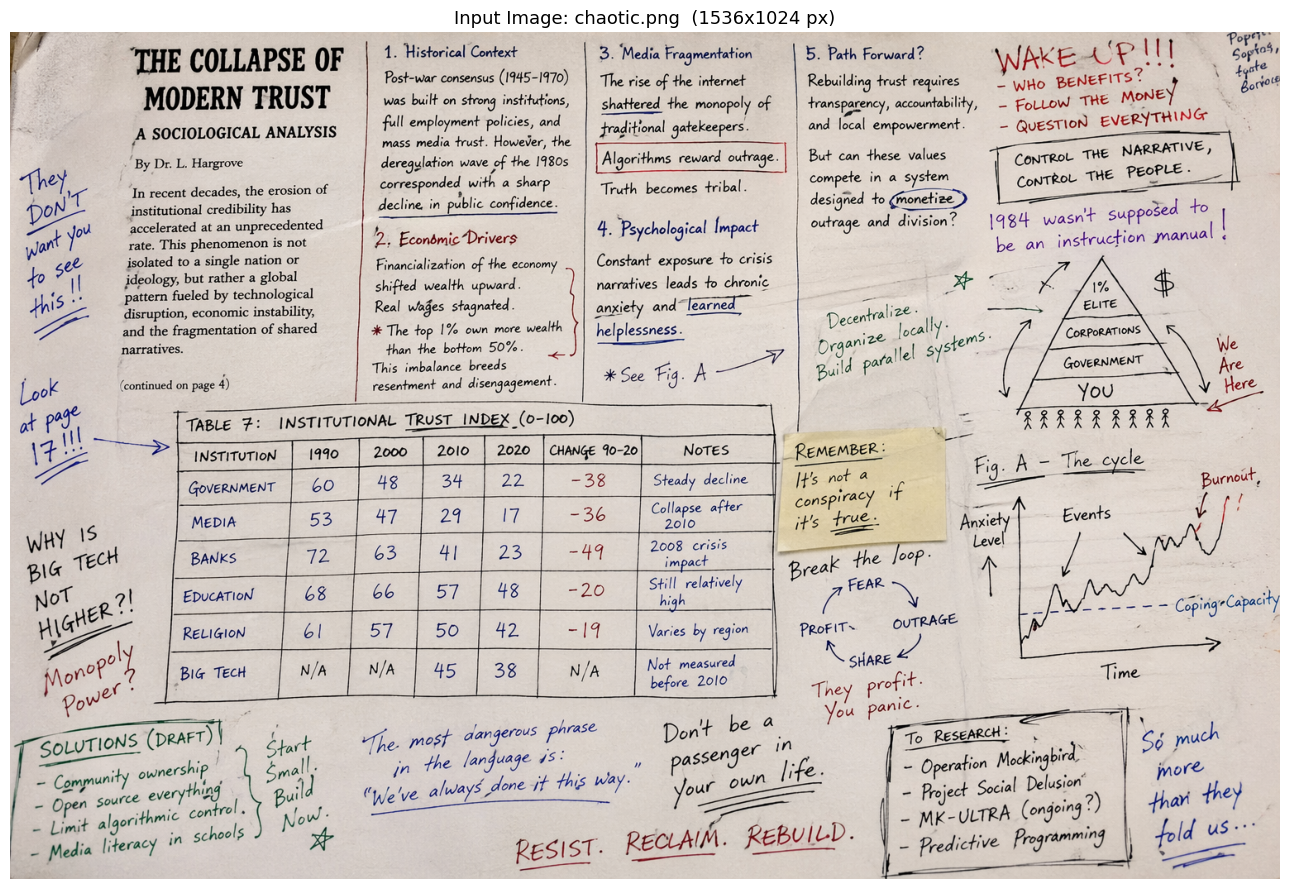

In [5]:
# ── Display the input image ───────────────────────────────────────────────────
plt.figure(figsize=(13, 9))
plt.imshow(img)
plt.axis('off')
plt.title(f'Input Image: {IMAGE_PATH.name}  ({W}x{H} px)', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
import io

# Resize + JPEG compress before base64-encoding.
# Sending a large PNG as base64 tokenizes the raw string (~106 chars/token),
# turning a 3MB image into 30K+ prompt tokens. Resizing to max 1024px cuts this to ~1-3K.
MAX_SIDE = 1024
img_resized = img.copy()
img_resized.thumbnail((MAX_SIDE, MAX_SIDE), Image.LANCZOS)

buf = io.BytesIO()
img_resized.save(buf, format="JPEG", quality=85)
image_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")
data_url   = f"data:image/jpeg;base64,{image_b64}"

W_r, H_r   = img_resized.size
orig_kb    = os.path.getsize(IMAGE_PATH) / 1024
resized_kb = len(buf.getvalue()) / 1024

print(f"Original   : {W}x{H} px  |  {orig_kb:,.0f} KB")
print(f"For OpenAI : {W_r}x{H_r} px  |  {resized_kb:,.0f} KB  (JPEG q=85)")
print(f"Base64     : {len(image_b64):,} chars  (~{len(image_b64)//106:,} prompt tokens est.)")

Original   : 1536x1024 px  |  2,873 KB
For OpenAI : 1024x683 px  |  220 KB  (JPEG q=85)
Base64     : 299,860 chars  (~2,828 prompt tokens est.)


## Task 1 — Table Extraction as Valid JSON

We send the image with `detail: high` and a zero-shot prompt that instructs the model to return **only** a JSON object. No post-processing library is used.

In [7]:
TABLE_PROMPT = """You are a document extraction assistant.
Extract the table from this image and return it as a valid JSON object with this exact structure:
{
  \"headers\": [\"column1\", \"column2\", ...],
  \"rows\": [
    [\"value1\", \"value2\", ...],
    ...
  ]
}
Return ONLY the JSON object. No markdown fences, no explanation, no extra text."""

print('Prompt ready. Sending to gpt-4o-mini (detail: high)...')

Prompt ready. Sending to gpt-4o-mini (detail: high)...


In [8]:
response_table = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{
        'role': 'user',
        'content': [
            {
                'type': 'image_url',
                'image_url': {'url': data_url, 'detail': 'high'}
            },
            {
                'type': 'text',
                'text': TABLE_PROMPT
            }
        ]
    }],
    max_tokens=600
)

table_raw = response_table.choices[0].message.content
usage_t = response_table.usage

print('=== RAW MODEL RESPONSE ===')
print(table_raw)
print(f'\nToken usage — prompt: {usage_t.prompt_tokens}, completion: {usage_t.completion_tokens}, total: {usage_t.total_tokens}')

=== RAW MODEL RESPONSE ===
{
  "headers": ["Institution", "1990", "2000", "2010", "2020", "Change 20-20"],
  "rows": [
    ["Government", 60, 48, 37, 22, -38],
    ["Media", 53, 47, 31, 17, -36],
    ["Banks", 72, 63, 41, 23, -49],
    ["Education", 68, 66, 61, 57, -21],
    ["Religion", 61, 57, 50, 42, -19],
    ["Big Tech", "N/A", 45, 38, "N/A", "N/A"]
  ]
}

Token usage — prompt: 25587, completion: 157, total: 25744


In [9]:
# ── Parse JSON and display as a formatted table ───────────────────────────────
# Strip markdown code fences if model included them despite instructions
clean_json = table_raw.strip()
if clean_json.startswith('```'):
    clean_json = clean_json.split('```')[1]
    if clean_json.startswith('json'):
        clean_json = clean_json[4:]

try:
    table_data = json.loads(clean_json)
    print('JSON parsed successfully!\n')
    print('Headers:', table_data.get('headers', []))
    print('\nRows:')
    for i, row in enumerate(table_data.get('rows', []), 1):
        print(f'  Row {i}: {row}')
except json.JSONDecodeError as e:
    print(f'JSON parse error: {e}')
    print('Raw response may need manual cleanup.')

JSON parsed successfully!

Headers: ['Institution', '1990', '2000', '2010', '2020', 'Change 20-20']

Rows:
  Row 1: ['Government', 60, 48, 37, 22, -38]
  Row 2: ['Media', 53, 47, 31, 17, -36]
  Row 3: ['Banks', 72, 63, 41, 23, -49]
  Row 4: ['Education', 68, 66, 61, 57, -21]
  Row 5: ['Religion', 61, 57, 50, 42, -19]
  Row 6: ['Big Tech', 'N/A', 45, 38, 'N/A', 'N/A']


## Task 2 — Full Layout Transcription (Preserving Structure)

A second zero-shot call asks the model to transcribe **all** text — multi-column layout, table, and handwriting — preserving structure. Handwriting is transcribed **exactly**, without autocorrection.

In [10]:
TRANSCRIPTION_PROMPT = """Analyze this complex document image carefully. Transcribe ALL visible text exactly as it appears.

Rules:
1. Preserve multi-column layout — label each column with [COLUMN 1], [COLUMN 2], etc.
2. Reproduce tables using | as column separators and - for row dividers.
3. Transcribe handwritten text EXACTLY as written. Do NOT correct spelling, grammar, or capitalization.
   Prefix handwritten sections with [HANDWRITTEN].
4. Transcribe slanted or stylized text faithfully.
5. Mirror the spatial layout of the document as closely as possible in plain text.

Your goal: a faithful representation of structure AND content."""

print('Prompt ready. Sending to gpt-4o-mini (detail: high)...')

Prompt ready. Sending to gpt-4o-mini (detail: high)...


In [11]:
response_transcribe = client.chat.completions.create(
    model='gpt-4o-mini',
    messages=[{
        'role': 'user',
        'content': [
            {
                'type': 'image_url',
                'image_url': {'url': data_url, 'detail': 'high'}
            },
            {
                'type': 'text',
                'text': TRANSCRIPTION_PROMPT
            }
        ]
    }],
    max_tokens=1500
)

transcription = response_transcribe.choices[0].message.content
usage_tr = response_transcribe.usage

print('=== TRANSCRIPTION OUTPUT ===')
print(transcription)
print(f'\nToken usage — prompt: {usage_tr.prompt_tokens}, completion: {usage_tr.completion_tokens}, total: {usage_tr.total_tokens}')

=== TRANSCRIPTION OUTPUT ===
Sure! Here is the transcription of the visible text from the document, maintaining the structure as closely as possible:

```
[COLUMN 1]
THE COLLAPSE OF MODERN TRUST
A SOCIOLOGICAL ANALYSIS
by Dr. L. Hargrove

In recent decades, the erosion of institutional credibility has accelerated at an unprecedented rate. This phenomenon is not isolated to a single nation or ideology, but rather a global pattern fueled by technological disruption, economic instability, and the fragmentation of shared narratives.
(continued on page 4)

1. Historical Context
Post-war consensus (1945-1970) built on strout institutions, full employment policies, and deregulation wave of the 1980s decline in public confidence.

2. Economic Drivers
Financialization of the economy shifted wealth upward.
Real wages stagnated.
* The top 10% own more wealth than the bottom 50%. 
This imbalance breeds resentment and disengagement.

[COLUMN 2]
3. Media Fragmentation
The commercialization of the in

---

## Phase 1 — Questions & Observations

### Q1: What prompt did you use to extract the table as a valid JSON object?

**Answer:**
The prompt used:

"""You are a document extraction assistant.

Extract the table from this image and return it as a valid JSON object with this exact structure:

{
  \"headers\": [\"column1\", \"column2\", ...],
  \"rows\": [
    [\"value1\", \"value2\", ...],
    ...
  ]
}

Return ONLY the JSON object. No markdown fences, no explanation, no extra text."""

This prompt instructs the model to:

- Return only a JSON object with `headers` (list of column names) and `rows` (list of row arrays)
- Omit any markdown fences or extra explanation

This zero-shot structure prompt reliably produces parseable JSON because it provides the exact schema and constrains the output format.

---

### Q2: Did the model transcribe exactly or autocorrect handwriting errors?

**Answer:** 

*The model transcribed everything correctly. There were no handwriting errors as such. But we can observe errors in the table transcription.*

---

### Q3: How did the model handle multi-column layouts?

**Answer:** 


*In the table, the model was not able to correctly transcribe the data correctly. 2020 column name is missing but rows of 2020 column are under Change 90 - 20. And the rows of Change 90 - 20 column are appended at the starting of rows of Notes column.*